In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

### Funciones

In [10]:
def gaussiana(f, A, f0, sigma, y0):
    return A * np.exp(-((f - f0)**2) / (2 * sigma**2)) + y0

### Importando los datos

In [2]:
path_file = r"..\mediciones\clase2\clean\mediciones_parte1_clean.csv"

In [3]:
datos = pd.read_csv(path_file, sep=",")
datos.head(5)

,frecuencia,vpp,vpp_error
0,35.0,10.0,0.3
1,36.0,32.0,1.0
2,37.0,74.0,2.0
3,38.0,188.0,6.0
4,38.1,202.0,6.0


### Gráficamos las observaciones

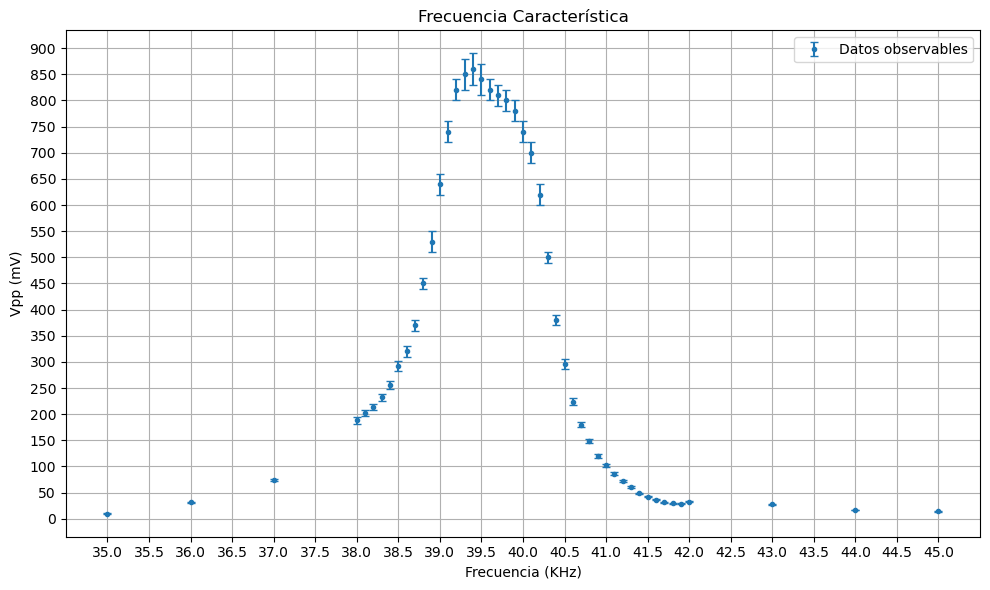

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

# observaciones
ax.errorbar(
    x=datos["frecuencia"],
    y=datos["vpp"],
    yerr=datos["vpp_error"],
    fmt='.',
    capsize=3,
    label="Datos observables"
)
ax.set_xticks(np.arange(35, 45.5, 0.5))
ax.set_yticks(np.arange(0, 950, 50))
ax.set_title("Frecuencia Característica")
ax.set_xlabel("Frecuencia (KHz)")
ax.set_ylabel("Vpp (mV)")
ax.legend()
ax.grid(True)
plt.tight_layout()

# guardamos 
path_save = r"..\graficos\clase2\observaciones.png"
plt.savefig(path_save, dpi=300, bbox_inches='tight')

plt.show()

### Ajuste gaussiano - rango completo

In [21]:
# Estimaciones iniciales
p0_guess = [
    datos["vpp"].max(),      # Amplitud aproximada
    39.5,                    # Valor central aproximada 
    1,                     # Ancho estimado sigma
    datos["vpp"].min()       # Nivel base
]

In [22]:
# realizamos un ajuste por mínimos cuadrados ponderados
popt, pcov = curve_fit(
    f =gaussiana,
    xdata=datos["frecuencia"],
    ydata=datos["vpp"],
    p0=p0_guess,
    sigma=datos["vpp_error"], 
    absolute_sigma=True
)

In [23]:
# Extraer los valores óptimos y sus errores (raíz de la diagonal de la covarianza)
A_opt, f0_opt, sigma_opt, y0_opt = popt
errores = np.sqrt(np.diag(pcov))
df0 = errores[1]  # Error de la frecuencia característica f0

print(f"Frecuencia característica f0 = ({f0_opt:.3f} ± {df0:.3f}) kHz")

Frecuencia característica f0 = (39.481 ± 0.004) kHz


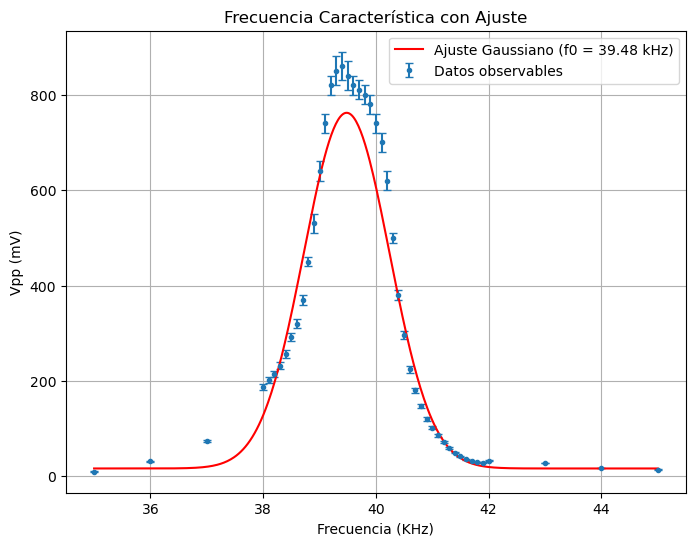

In [24]:
# 5. Graficar los datos y la curva ajustada
f_fit = np.linspace(datos['frecuencia'].min(), datos['frecuencia'].max(), 500)
vpp_fit = gaussiana(f_fit, *popt)

plt.figure(figsize=(8, 6))
plt.errorbar(datos['frecuencia'], datos['vpp'], yerr=datos['vpp_error'], fmt='.', label='Datos observables', capsize=3)
plt.plot(f_fit, vpp_fit, 'r-', label=f'Ajuste Gaussiano (f0 = {f0_opt:.2f} kHz)')

plt.xlabel('Frecuencia (KHz)')
plt.ylabel('Vpp (mV)')
plt.title('Frecuencia Característica con Ajuste')
plt.grid(True)
plt.legend()
plt.show()

### Ajuste gaussiano - zona de resonancia

In [25]:
df_pico = datos[(datos['frecuencia'] >= 37.5) & (datos['frecuencia'] <= 42.0)]

In [46]:
# el pico se vuelve mas angosto

p0_guess = [
    df_pico['vpp'].max(),  # Amplitud estimada (~860)
    39.5,                  # Frecuencia central estimada
    0.68,                   # Ancho estimado (sigma)
    df_pico['vpp'].min()   # Nivel base del piso
]


In [47]:
popt, pcov = curve_fit(
    gaussiana, 
    df_pico['frecuencia'], 
    df_pico['vpp'], 
    p0=p0_guess, 
    sigma=df_pico['vpp_error'], 
    absolute_sigma=True
)

In [48]:
# Extraer los valores óptimos y sus errores (raíz de la diagonal de la covarianza)
A_opt, f0_opt, sigma_opt, y0_opt = popt
errores = np.sqrt(np.diag(pcov))
df0 = errores[1]  # Error de la frecuencia característica f0

print(f"Frecuencia característica f0 = ({f0_opt:.3f} ± {df0:.3f}) kHz")

Frecuencia característica f0 = (39.490 ± 0.003) kHz


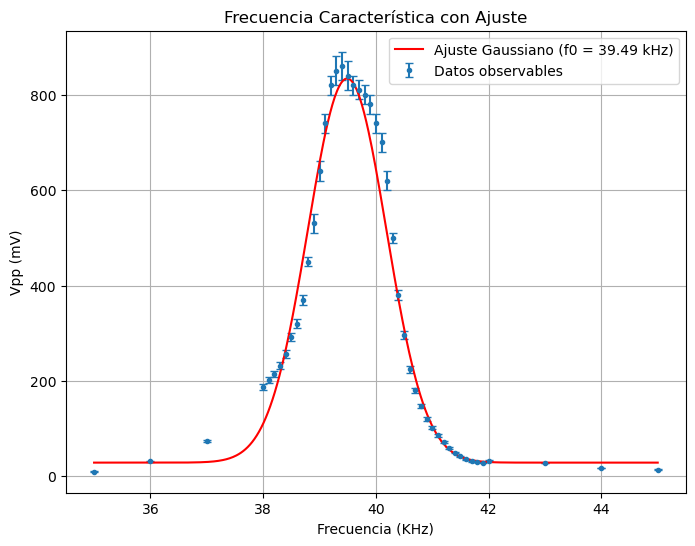

In [49]:
# 5. Graficar los datos y la curva ajustada
f_fit = np.linspace(datos['frecuencia'].min(), datos['frecuencia'].max(), 500)
vpp_fit = gaussiana(f_fit, *popt)

plt.figure(figsize=(8, 6))
plt.errorbar(datos['frecuencia'], datos['vpp'], yerr=datos['vpp_error'], fmt='.', label='Datos observables', capsize=3)
plt.plot(f_fit, vpp_fit, 'r-', label=f'Ajuste Gaussiano (f0 = {f0_opt:.2f} kHz)')

plt.xlabel('Frecuencia (KHz)')
plt.ylabel('Vpp (mV)')
plt.title('Frecuencia Característica con Ajuste')
plt.grid(True)
plt.legend()
plt.show()